<a href="https://colab.research.google.com/github/Kavish1504/Topsis-Text-Classification/blob/main/Topsis_for_Pre_Trained_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import pipeline
from sklearn.metrics import accuracy_score, f1_score
from datasets import load_dataset

In [ ]:
dataset=load_dataset("stanfordnlp/sst2")
test_data=dataset["validation"]
N=int(input("Enter the number of texts for testing: "))
texts=test_data["sentence"][:N]
labels=test_data["label"][:N]
print("Loaded", len(texts), "test samples")

Enter the number of texts for testing: 50
Loaded 50 test samples


In [ ]:
def TOPSIS(matrix, weights, impacts):
    matrix=matrix / np.sqrt((matrix ** 2).sum(axis=0))
    matrix=matrix * weights
    ideal_best=[]
    ideal_worst=[]

    for i in range(len(impacts)):
        if impacts[i] == "+":
            ideal_best.append(matrix[:, i].max())
            ideal_worst.append(matrix[:, i].min())
        else:
            ideal_best.append(matrix[:, i].min())
            ideal_worst.append(matrix[:, i].max())

    ideal_best=np.array(ideal_best)
    ideal_worst=np.array(ideal_worst)
    d_best=np.sqrt(((matrix - ideal_best)  ** 2).sum(axis=1))
    d_worst=np.sqrt(((matrix - ideal_worst) ** 2).sum(axis=1))
    scores=d_worst / (d_best + d_worst)
    best_index=np.argmax(scores)
    return best_index, scores

In [ ]:
model_configs=[
    {
        "id"       : "cardiffnlp/twitter-roberta-base-sentiment-latest",
        "name"     : "TwitterRoBERTa",
        "pos_label": "positive"
    },
    {
        "id"       : "siebert/sentiment-roberta-large-english",
        "name"     : "SieBERT",
        "pos_label": "POSITIVE"
    },
    {
        "id"       : "finiteautomata/bertweet-base-sentiment-analysis",
        "name"     : "BERTweet",
        "pos_label": "POS"
    },
    {
        "id"       : "assemblyai/bert-large-uncased-sst2",
        "name"     : "AssemblyAI-BERT",
        "pos_label": "POSITIVE"
    },
    {
    "id"       : "textattack/bert-base-uncased-SST-2",
    "name"     : "TextAttack-BERT",
    "pos_label": "LABEL_1"
    },
]

In [ ]:
results=[]
model_ids=[cfg["id"]   for cfg in model_configs]
model_names=[cfg["name"] for cfg in model_configs]

for cfg in model_configs:
    print("\nEvaluating:", cfg["id"])
    clf=pipeline("text-classification", model=cfg["id"], truncation=True)
    start=time.time()
    preds=clf(list(texts))
    elapsed=time.time() - start
    y_pred=[1 if p["label"].lower() == cfg["pos_label"].lower() else 0 for p in preds]
    confidences=[p["score"] for p in preds]
    acc =accuracy_score(labels, y_pred)
    f1=f1_score(labels, y_pred, zero_division=0)
    avg_conf=np.mean(confidences)

    print(f"Accuracy        = {acc:.3f}")
    print(f"F1 Score        = {f1:.3f}")
    print(f"Avg Confidence  = {avg_conf:.3f}")
    print(f"Inference Time  = {elapsed:.2f} sec")

    results.append([acc, f1, avg_conf, elapsed])


Evaluating: cardiffnlp/twitter-roberta-base-sentiment-latest


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Accuracy        = 0.880
F1 Score        = 0.857
Avg Confidence  = 0.800
Inference Time  = 7.97 sec

Evaluating: siebert/sentiment-roberta-large-english


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Accuracy        = 0.940
F1 Score        = 0.939
Avg Confidence  = 0.980
Inference Time  = 10.31 sec


In [ ]:
decision_matrix=np.array(results)
weights=[1, 1, 1, 1]
impacts=["+", "+", "+", "-"]
best_idx, scores=TOPSIS(decision_matrix, weights, impacts)
print("\nTOPSIS Scores:", scores)
print("Best Model:", model_ids[best_idx])


TOPSIS Scores: [0.85866044 0.56252524 0.87822028 0.09335737 0.92064237]
Best Model: textattack/bert-base-uncased-SST-2



Final Results Table:

             Model  Accuracy  F1 Score  Avg Confidence  Inference Time  \
0   TwitterRoBERTa      0.88  0.857143        0.799516        7.972893   
1          SieBERT      0.94  0.941176        0.998474       25.683885   
2         BERTweet      0.88  0.863636        0.851812        8.957217   
3  AssemblyAI-BERT      0.52  0.000000        0.952331       25.608130   
4  TextAttack-BERT      0.94  0.938776        0.980122       10.306909   

   TOPSIS Score  
0      0.858660  
1      0.562525  
2      0.878220  
3      0.093357  
4      0.920642  


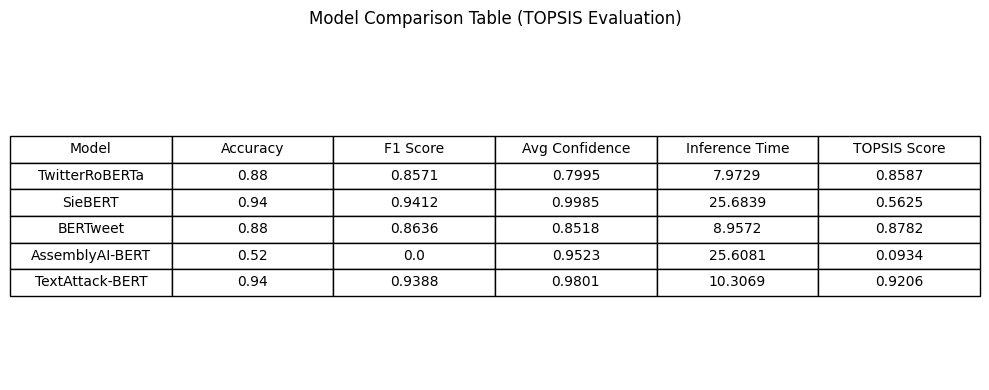

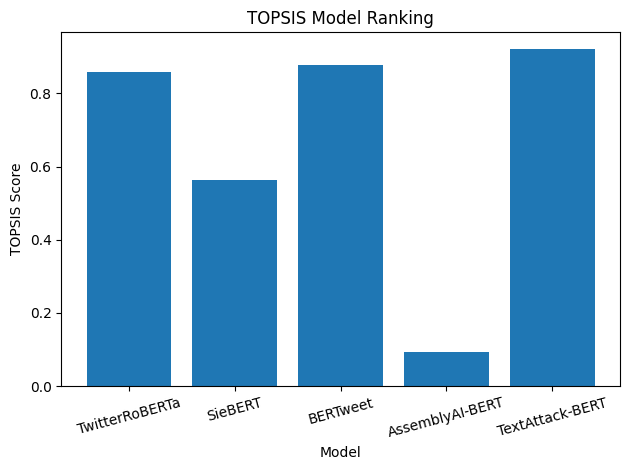

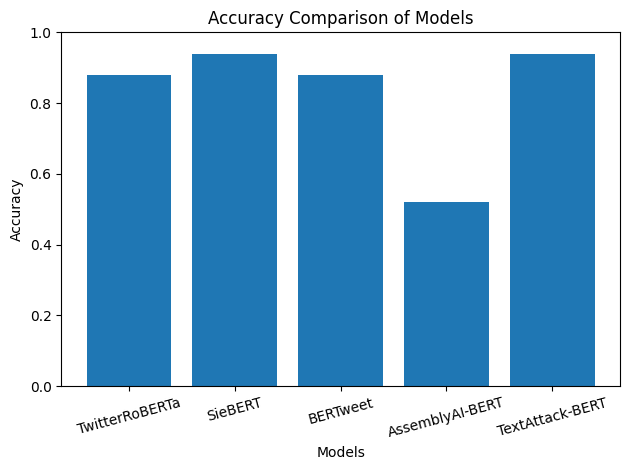

In [ ]:
df=pd.DataFrame(results, columns=[
    "Accuracy",
    "F1 Score",
    "Avg Confidence",
    "Inference Time"
])
df["Model"]=model_names
df["TOPSIS Score"]=scores

df=df[["Model", "Accuracy", "F1 Score", "Avg Confidence", "Inference Time", "TOPSIS Score"]]
print("\nFinal Results Table:\n")
print(df)

# Table Display
plt.figure(figsize=(10, 4))
plt.axis('off')
df_rounded = df.round(4)

table=plt.table(
    cellText=df_rounded.values,
    colLabels=df.columns,
    loc='center',
    cellLoc='center'
)

table.scale(1, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.title("Model Comparison Table (TOPSIS Evaluation)", pad=20)
plt.tight_layout()
plt.show()

# TOPSIS Graph
plt.figure()
plt.bar(df["Model"], df["TOPSIS Score"])
plt.title("TOPSIS Model Ranking")
plt.xlabel("Model")
plt.ylabel("TOPSIS Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Accuracy Graph
plt.figure()
plt.bar(df["Model"], df["Accuracy"])
plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


